In [1]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster

main_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre"

# Plotting for Porto Alegre

This notebook uses the rasters generated before to plot the results of the PortoAlegre exercise. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [2]:
config = configparser.ConfigParser()
config.read(main_path + '/config.cfg')

swot_project = SwotProject(config)
# print(swot_project)

Data path already exists in /data/scratch/globc/bonassies/data or download is set to False
SWOT data already exists in /data/scratch/globc/bonassies/data/SWOT or download is set to False
SWOT project already exists in /data/scratch/globc/bonassies/data/SWOT/PortoAlegre or download is set to False
Geopackage already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/gpkg_combined or make_gpkg is set to False
TIFF path already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/rasters or make_tiff is set to False
No automatic download, please use the Downloader object to download the data


In [3]:
swot_project.find_raster()
# print(swot_project.rasters_list)


Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [4]:
# swot_project.Rasterizer.gdalwarp_raster_to_swot_bbox_and_size(
#     Path('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/ESA_WorldCover_10m_merged_32722_clip.tif'),
#     32722,
#     "near"
# )

In [5]:
# takes around 2 minutes for 5 raster files of 1.65Go
swot_project.create_collection()
# swot_project.floodmask

Opening SWOT raster at time: 2024-05-06 11:46:43


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2025-03-15 11:02:55


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2025-04-05 07:47:58


...

Opening SWOT raster at time: 2024-03-25 18:16:34


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-04-15 15:01:40


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassie

We can then create the plot object that we will use to plot the data.

In [6]:
plot_obj = PlotRaster(
    swot_project,
    save_fig=True,
    show_fig=True
    )

Finally, we can plot the data using the plot object.

Below, a function to plot the control area and histograms associated with the control area.

# Gamma tot

In [ ]:
# plot_obj.plot_control_maps_and_histograms(
#     'gamma_tot', 
#     time_selection="2024-05-06",
#     cmap=Colormap("seaborn:mako").to_matplotlib(),
#     y_label="Porto Alegre, Rio Grande do Sul\nEMSN 192",
#     vmin=0,
#     vmax=1,
#     )


Plot mean histograms with the dates that compose the mean.

In [ ]:
# fig,ax = plot_obj.plot_mean_hist_computation(
#     'gamma_tot',
#     hist_range=(0,1),
#     add_legend=False
# )

Below, the function to plot a map.

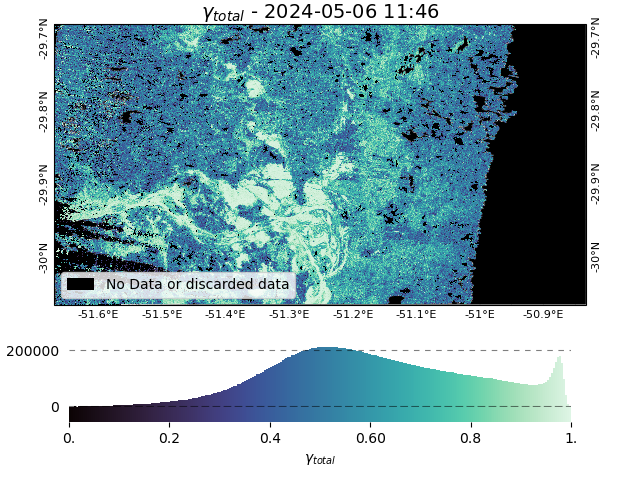

In [21]:
# takes around 1 minute
fig, ax = plot_obj.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-05-06",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False
    )

Below a function to plot an histogram.

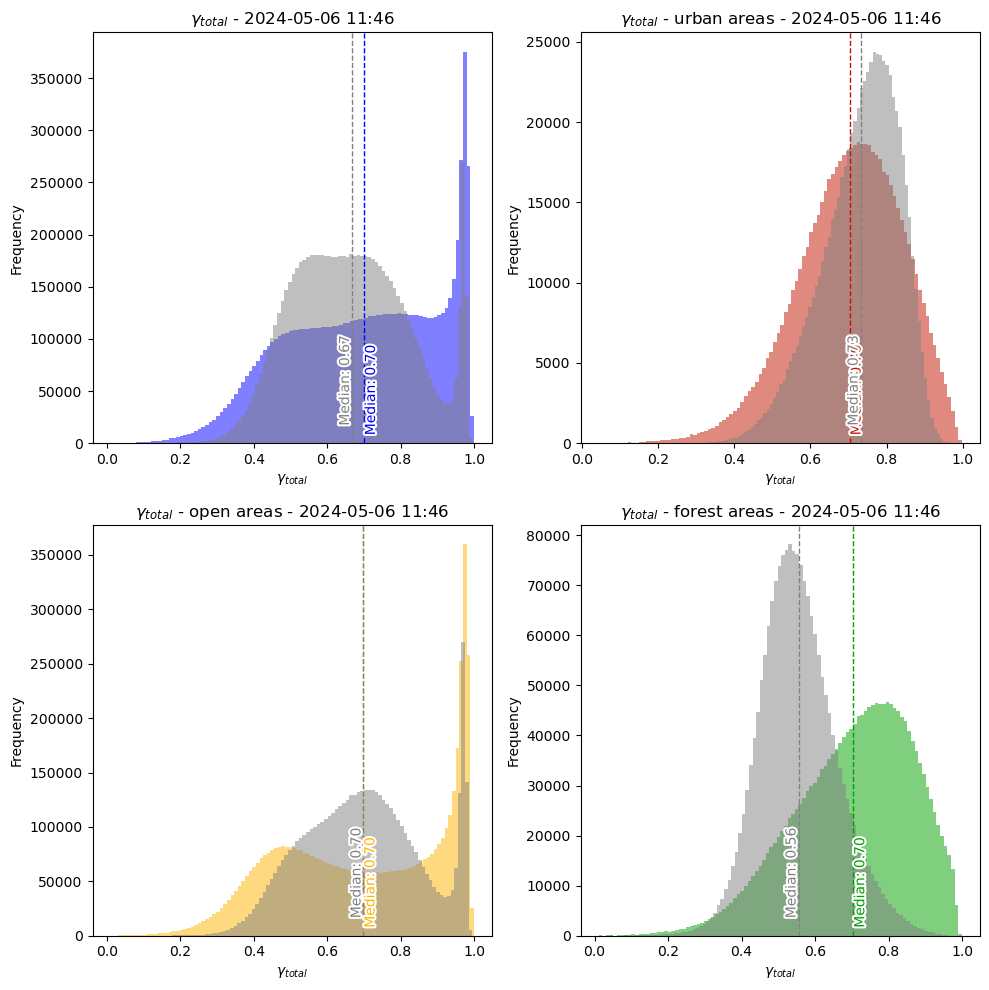

In [7]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, ax = plt.subplots(2,2, figsize=(10, 10))

fig, ax[0,0] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[0,0],
    save_fig=False,
    show_fig=False,
    )
fig, ax[0,1] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection='urban',
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[0,1],
    save_fig=False,
    show_fig=False,
    )
fig, ax[1,0] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection='open',
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[1,0],
    save_fig=False,
    show_fig=False,
    )
fig, ax[1,1] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection='forest',
    time_selection="2024-05-06",
    use_seaborn=False,
    fig=fig,
    ax=ax[1,1],
    save_fig=False,
    show_fig=False,
    )

fig.tight_layout()
fig.show()

And then, the function to combine maps and histograms.

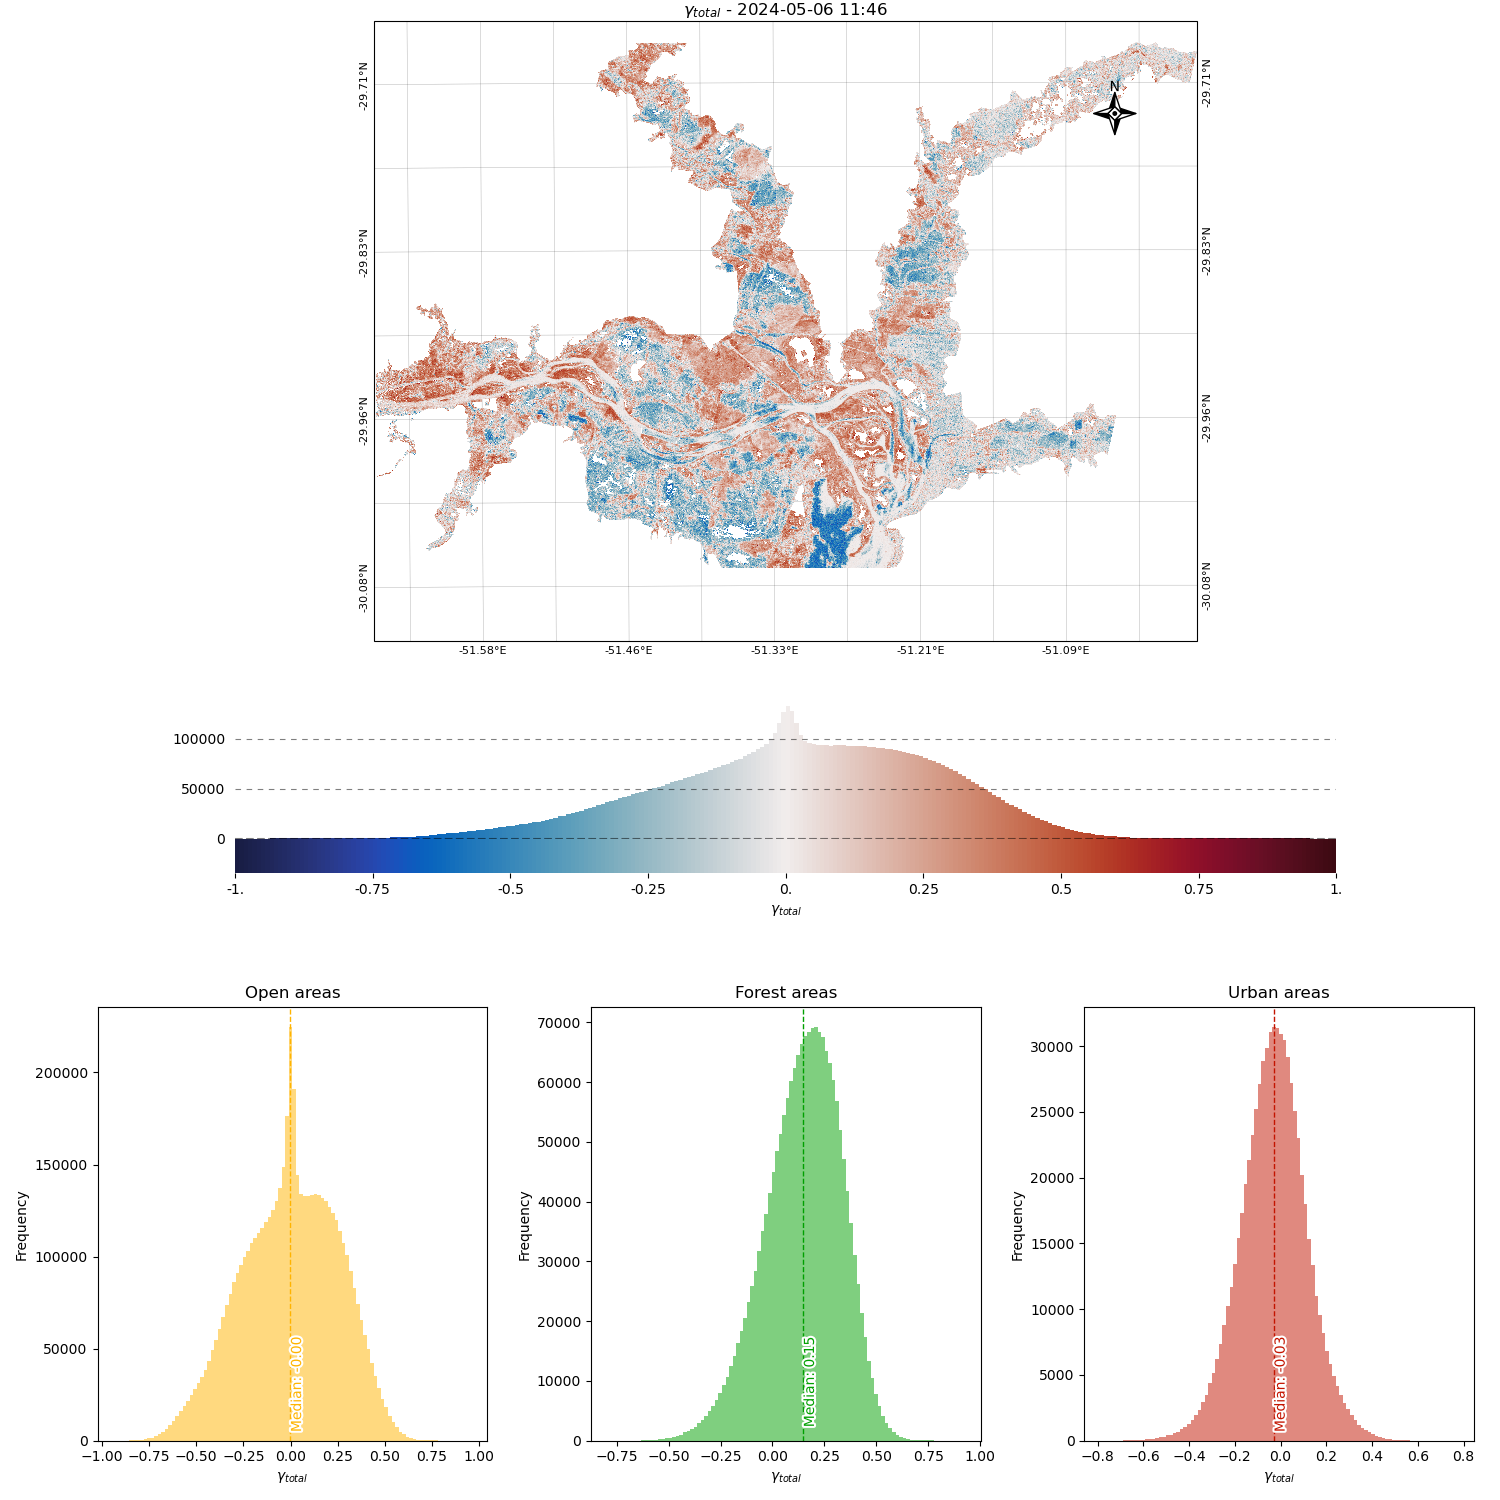

In [8]:
# takes around 1 minute 15s for matplotlib method, 4 minutes for seaborn method
fig, ax = plot_obj.plot_map_with_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="diff",
    # world_cover_mask=['urban'],
    time_selection="2024-05-06",
    vmin=-1,
    vmax=1,
    add_bkg=False,
    # cmap=Colormap("seaborn:mako").to_matplotlib(),
    cmap=Colormap("cmocean:balance").to_matplotlib(),
    use_seaborn=False
    )

In [ ]:
# from skimage.filters import rank
# from skimage.morphology import disk
# import numpy as np

# footprint = disk(2)

# # data = plot_obj.swot_collection.swot_flood_rasters_flood.gamma_tot.values[0]
# data = plot_obj.swot_collection.swot_mean.gamma_tot.values
# cv = data > 0.8
# # norm between 0 and 255
# data = data * 255
# mask = data == np.nan
# data[mask] = 0

# majority_filt = rank.majority(data.astype(np.uint8), footprint=footprint, mask=~mask)
# grad = rank.gradient(data.astype(np.uint8), footprint=footprint, mask=~mask)
# entropy = rank.entropy(data.astype(np.uint8), footprint=footprint, mask=~mask)

# fig, ax = plt.subplots(2,2, figsize=(20, 20))

# im = ax[0,0].imshow(data, cmap=Colormap("seaborn:mako").to_matplotlib())
# plt.colorbar(im, ax=ax[0,0])
# ax[0,0].set_title('Original image')

# im = ax[0,1].imshow(majority_filt, cmap=Colormap("seaborn:mako").to_matplotlib())
# plt.colorbar(im, ax=ax[0,1])
# ax[0,1].set_title('Majority filter')

# im = ax[1,1].imshow(grad, cmap='cividis')
# plt.colorbar(im, ax=ax[1,1])
# ax[1,1].set_title('Gradient')

# im = ax[1,0].imshow(entropy, cmap='magma')
# plt.colorbar(im, ax=ax[1,0])
# ax[1,0].set_title('Entropy')

# plt.show()

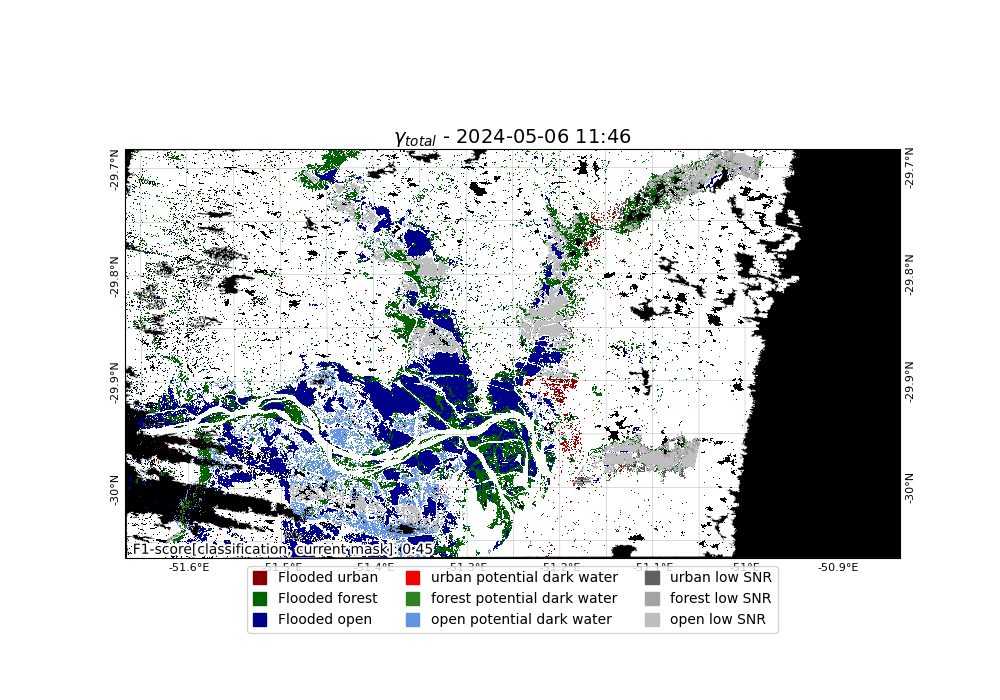

In [7]:

print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    threshold_SNR=0.5,
    threshold_gamma=0.5, #swot
    # threshold_gamma=-0.15, #diff
    time_selection="2024-05-06",
    add_uncertainty=True,
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    # comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )


# sigma 0

In [1]:
fig,ax = plot_obj.plot_map(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    cmap= 'viridis',
    vmin=-20,
    vmax=40,
    add_bkg=False,
    )

NameError: name 'plot_obj' is not defined

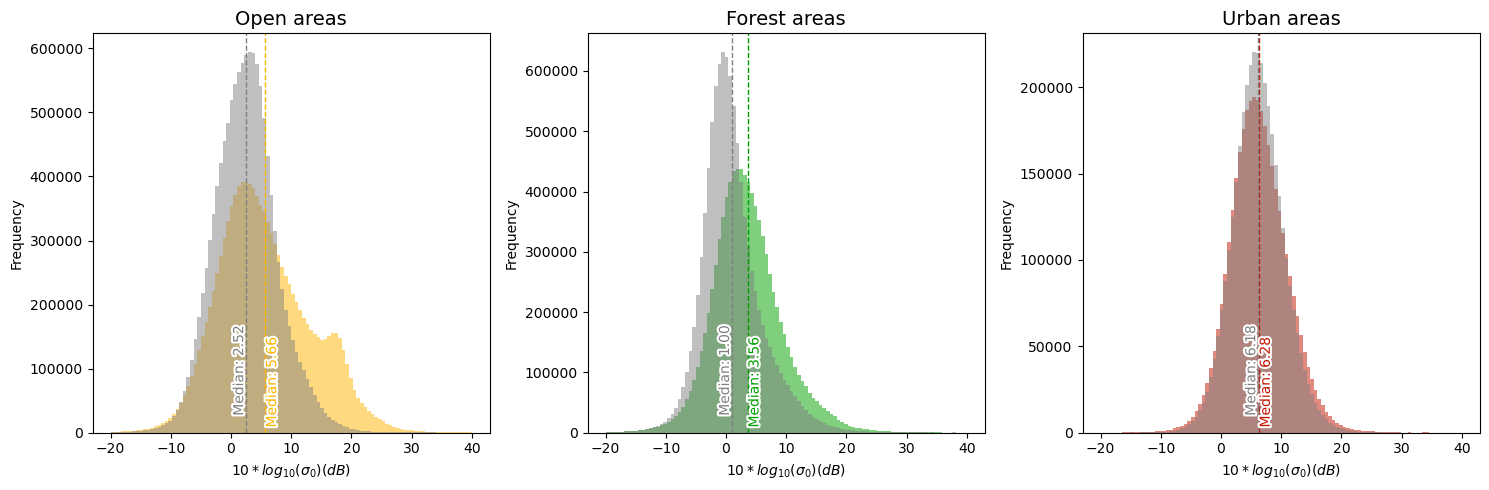

In [25]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    range_hist=(-20, 40),
    use_seaborn=False
    )

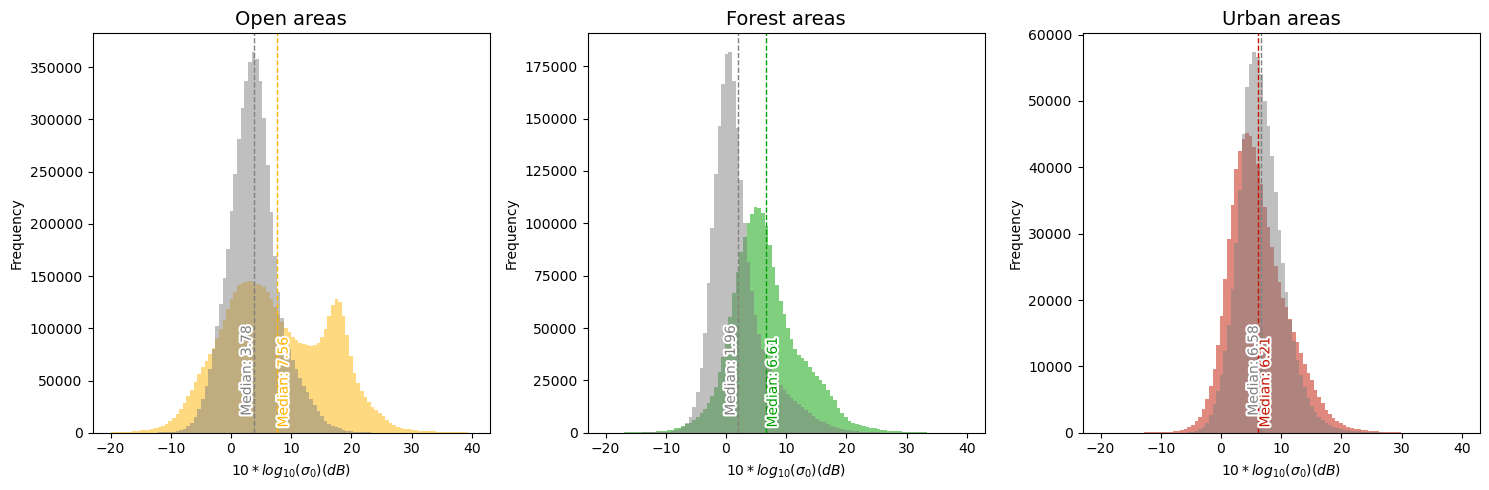

In [26]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="flood",
    data_type="swot",
    time_selection="2024-05-06",
    range_hist=(-20, 40),
    use_seaborn=False
    )

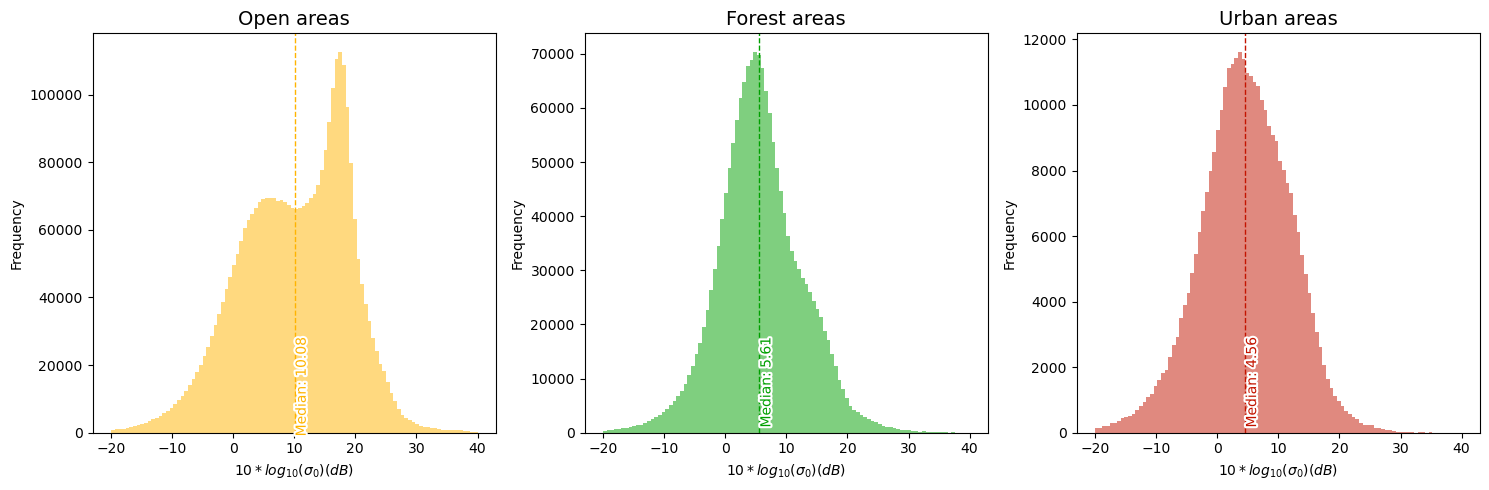

In [28]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="flood",
    data_type="diff",
    time_selection="2024-05-06",
    range_hist=(-20, 40),
    use_seaborn=False
    )

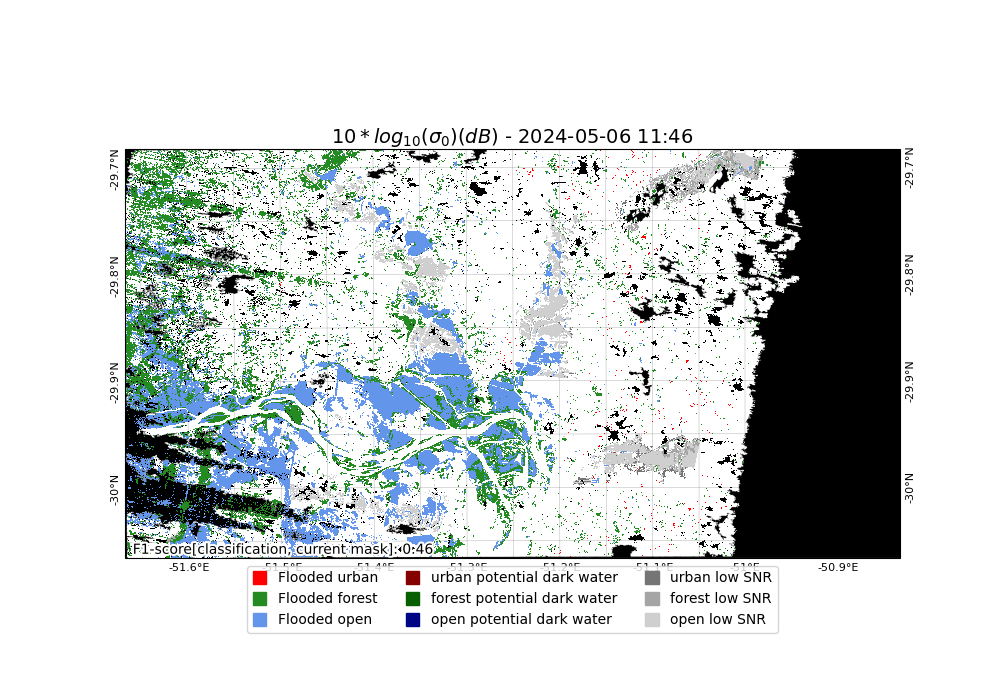

In [35]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":5, "open":10},
    time_selection="2024-05-06",
    threshold_gamma=0.5,
    threshold_SNR=0.5,
    add_uncertainty=True,
    urban_diff=True,
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    # comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

# Coherent_power

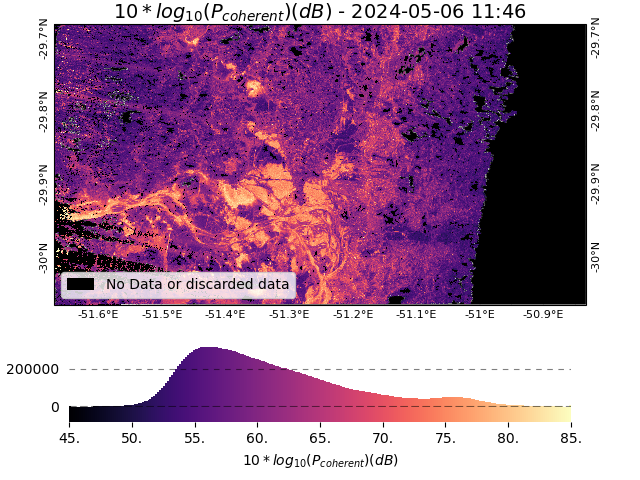

In [33]:
fig,ax = plot_obj.plot_map(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    cmap= 'magma',
    vmin=45,
    vmax=85,
    add_bkg=False,
    )

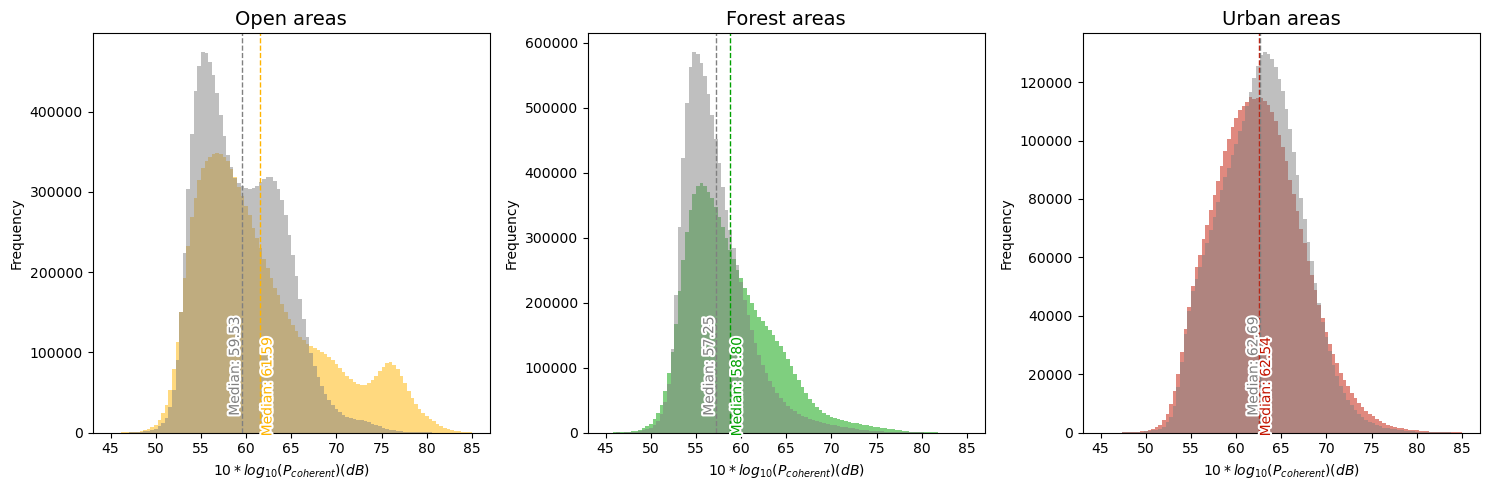

In [30]:
fig, ax = plot_obj.plot_all_histograms(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    range_hist=(45, 85),
    use_seaborn=False
    )

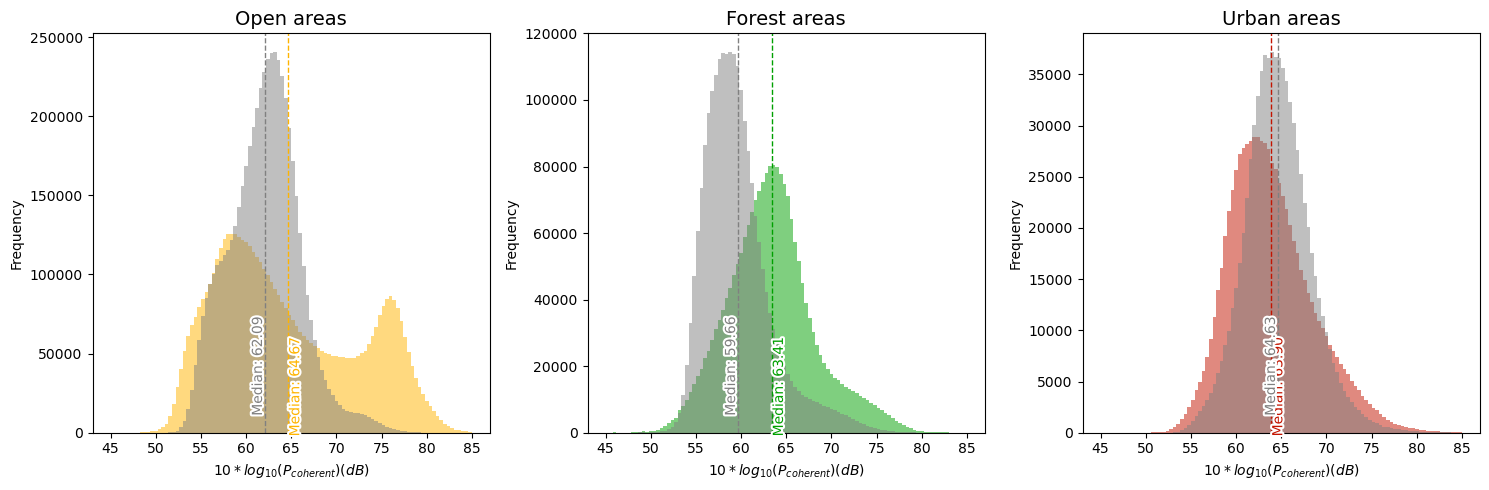

In [31]:
fig, ax = plot_obj.plot_all_histograms(
    variable="coherent_power",
    data_area="flood",
    data_type="swot",
    time_selection="2024-05-06",
    range_hist=(45, 85),
    use_seaborn=False
    )

/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


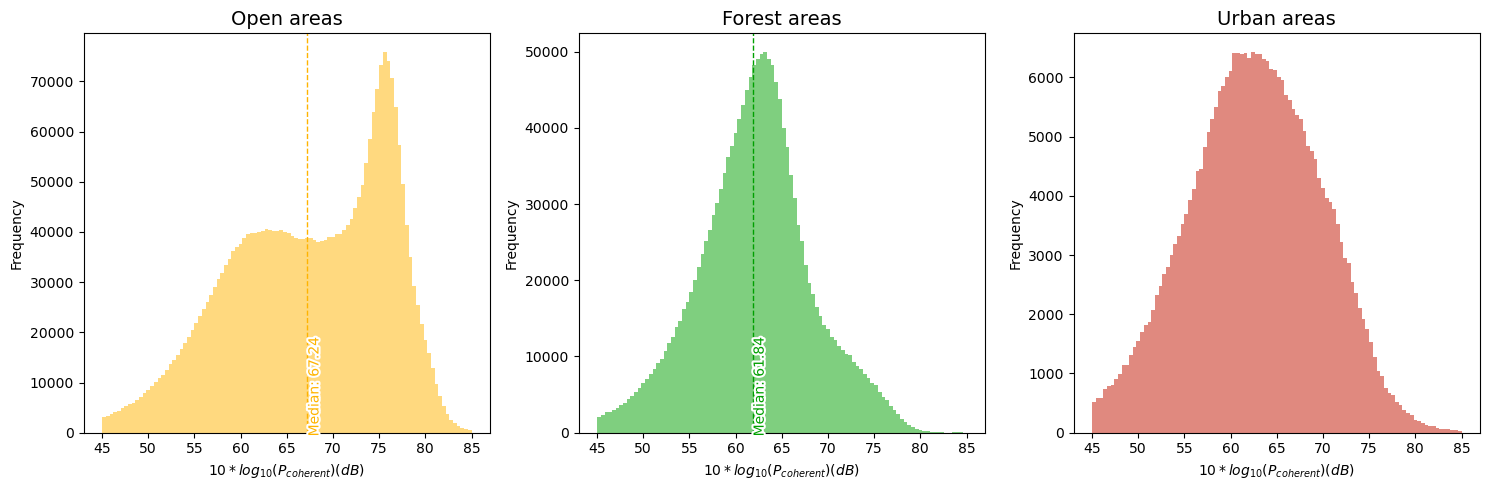

In [32]:
fig, ax = plot_obj.plot_all_histograms(
    variable="coherent_power",
    data_area="flood",
    data_type="diff",
    time_selection="2024-05-06",
    range_hist=(45, 85),
    use_seaborn=False
    )

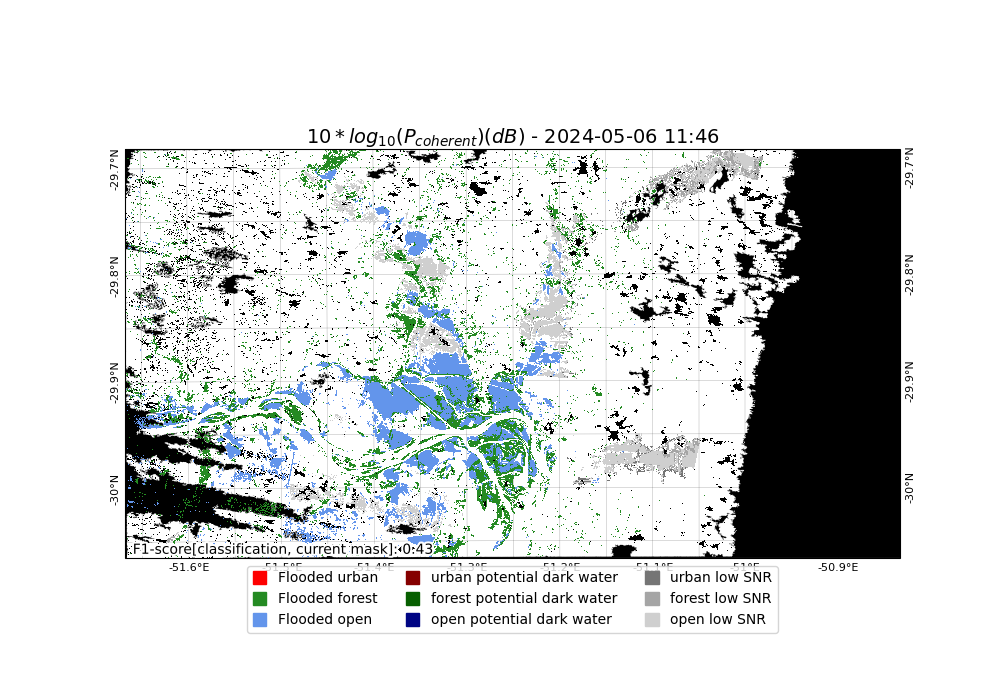

In [37]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":62, "open":70},
    time_selection="2024-05-06",
    add_uncertainty=True,
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    # comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

# merge mask

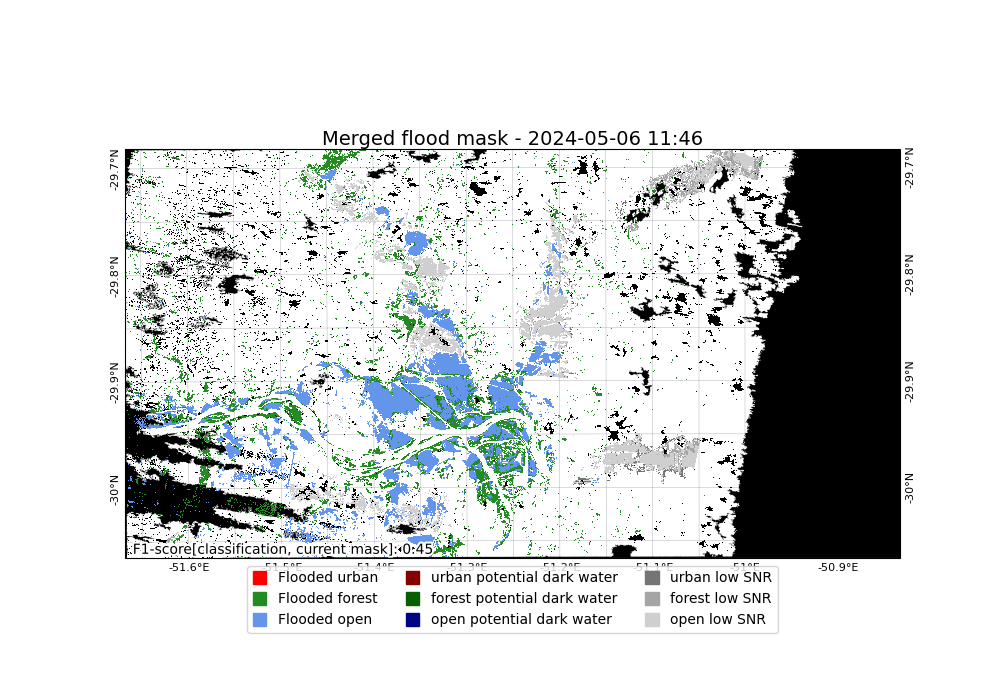

In [38]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":62, "open":70},
    time_selection="2024-05-06",
    add_uncertainty=True,
    )
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":5, "open":10},
    time_selection="2024-05-06",
    threshold_gamma=0.5,
    threshold_SNR=0.5,
    add_uncertainty=True,
    urban_diff=True,
    )
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    threshold_SNR=0.5,
    threshold_gamma=0.5, #swot
    # threshold_gamma=-0.15, #diff
    time_selection="2024-05-06",
    add_uncertainty=True,
    )

print('Merging flood masks...')
plot_obj.swot_collection.merge_flood_masks(data_area="global", data_type="swot", filter_variable="sig0")

print("Plotting merged flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="merged",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    # comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )


# Score

In [7]:
rasterizer = swot_project.Rasterizer
rasterizer.gdalwarp_raster_to_swot_bbox_and_size(
    swot_project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722.tif"),
    swot_project.CRS,
    'near'
)

>>> Converting the AUXILARY rasters to tiff
gdalwarp -s_srs EPSG:32722 -t_srs EPSG:32722 -te 435541.8049701032 6673862.735219697 516055.583907234 6716342.207199959 -ts 8052.0 4248.0 -r near -of GTiff /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/FLoodML_20240506T133149_cut_32722.tif /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif
Creating output file that is 8052P x 4248L.
Processing /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/FLoodML_20240506T133149_cut_32722.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


In [9]:
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    threshold_SNR=0.5,
    threshold_gamma=0.5, #swot
    # threshold_gamma=-0.15, #diff
    time_selection="2024-05-06",
    add_uncertainty=True,
    )

csi, f1, kappa = plot_obj.swot_collection.compute_scores(
    variable="gamma_tot",
    compared_raster_path=swot_project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
    data_area="flood",
    data_type="swot",
    time_selection="2024-05-06",
    water_value=1,
    nan_value=-9999
    )
print("Flooded Area")
print("SWOT x FM       ", round(csi * 100, 2), round(f1 * 100, 2), round(kappa * 100, 2))

csi, f1, kappa = plot_obj.swot_collection.compute_scores(
    variable="gamma_tot",
    compared_raster_path="classification",
    data_area="flood",
    data_type="swot",
    time_selection="2024-05-06",
    water_value=1,
    nan_value=-9999
    )
print("SWOT x classif  ", round(csi * 100, 2), round(f1 * 100, 2), round(kappa * 100, 2))


csi, f1, kappa = plot_obj.swot_collection.compute_scores(
    variable="classification",
    compared_raster_path=swot_project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
    data_area="flood",
    data_type="swot",
    time_selection="2024-05-06",
    water_value=1,
    nan_value=-9999
    )
print("classif x FM    ", round(csi * 100, 2), round(f1 * 100, 2), round(kappa * 100, 2))

#############
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    threshold_SNR=0.5,
    threshold_gamma=0.5, #swot
    # threshold_gamma=-0.15, #diff
    time_selection="2024-05-06",
    add_uncertainty=True,
    )

csi, f1, kappa = plot_obj.swot_collection.compute_scores(
    variable="gamma_tot",
    compared_raster_path=swot_project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    water_value=1,
    nan_value=-9999
    )
print("Global Area")
print("SWOT x FM       ", round(csi * 100, 2), round(f1 * 100, 2), round(kappa * 100, 2))

csi, f1, kappa = plot_obj.swot_collection.compute_scores(
    variable="gamma_tot",
    compared_raster_path="classification",
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    water_value=1,
    nan_value=-9999
    )
print("SWOT x classif  ", round(csi * 100, 2), round(f1 * 100, 2), round(kappa * 100, 2))

csi, f1, kappa = plot_obj.swot_collection.compute_scores(
    variable="classification",
    compared_raster_path=swot_project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
    data_area="global",
    data_type="swot",
    time_selection="2024-05-06",
    water_value=1,
    nan_value=-9999
    )
print("classif x FM    ", round(csi * 100, 2), round(f1 * 100, 2), round(kappa * 100, 2))

/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Flooded Area
SWOT x FM        40.31 57.46 23.52
SWOT x classif   44.98 62.05 67.42


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


classif x FM     29.53 45.59 32.61
Global Area
SWOT x FM        35.27 52.14 77.99
SWOT x classif   38.07 55.15 83.71
classif x FM     23.57 38.15 74.12
